
# 📊 03_Statistical_Modeling.ipynb
Statistical Time Series Forecasting for Tunisia Temperature Data (1950-2025)

Structure:
1. Environment Setup & Data Prep
2. Helper Functions (Metrics, Visualization)
3. Model Implementations (AR, MA, ARMA, ARIMA, SARIMA)
4. Model Comparison & Export



In [3]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.7 MB 4.5 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.7 MB 4.9 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.7 MB 5.2 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.7 MB 5.6 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.7 MB 5.6 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.7 MB 5.7 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.7 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 5.8 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   --------------

In [4]:
# ==================== 🛠️ 1. ENVIRONMENT CONFIGURATION ====================
"""
🔧 Ensures reproducibility and checks critical dependencies
"""
import sys  # System-specific parameters and functions
print(f"Python version: {sys.version}")  # Print Python version for reproducibility
print(f"Pandas version: {pd.__version__}")  # Show Pandas version (will print after imports)


Python version: 3.9.23 (main, Jun  5 2025, 13:25:08) [MSC v.1929 64 bit (AMD64)]
Pandas version: 2.1.3


In [5]:
# ==================== 📦 2. IMPORTS (Organized by Functionality) ====================

# ----- Core Scientific Computing -----
import pandas as pd  # Data manipulation and analysis
import numpy as np  # Numerical computing
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns  # Enhanced visualization

# ----- Statistical Models -----
from statsmodels.tsa.arima.model import ARIMA  # ARIMA modeling
from statsmodels.tsa.statespace.sarimax import SARIMAX  # Seasonal ARIMA

# ----- Advanced Metrics -----
from sklearn.metrics import (
    explained_variance_score,  # Explained variance beyond R²
    max_error  # Worst-case error
)
from scipy.stats import (
    pearsonr,  # Linear correlation
    spearmanr,  # Monotonic correlation
    kendalltau  # Ordinal association
    
)
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import (
    mse,  # Mean squared error (alternative implementation)
    rmse,  # Root mean squared error
    aic,  # Akaike Information Criterion
    bic  # Bayesian Information Criterion
)

# ----- Utilities -----
from math import sqrt  # Square root for RMSE
import warnings  # Warning control
warnings.filterwarnings("ignore", category=UserWarning)  # Suppress non-critical warnings

# ----- MLflow for Experiment Tracking -----
import mlflow # Experiment tracking and model management
import mlflow.statsmodels # For statsmodels integration
import mlflow.sklearn # For metrics logging


In [6]:
# ==================== 🗃️ 3. DATA LOADING  ====================
"""
📂 Load and validate the preprocessed temperature data
"""

def load_preprocessed_data():
    """
    Loads hourly temperature data with robust validation
    
    Returns:
        pd.DataFrame: Validated time-indexed temperature data
    
    Raises:
        ValueError: If data quality checks fail
    """
    # ----- Data Loading -----
    try:
        df = pd.read_csv(
            r"C:\Users\yosrc\OneDrive\Desktop\1950-2025 temp\data\processed\temperature_hourly.csv",
            parse_dates=['datetime'],
            index_col='datetime'
        )
    except FileNotFoundError:
        raise FileNotFoundError("Temperature data file not found at specified path")

    # ----- Frequency Enforcement -----
    df = df.asfreq("H")  # Set hourly frequency
    
    # ----- Data Quality Checks -----
    if df.isnull().values.any():  # Corrected null check
        null_counts = df.isnull().sum()
        raise ValueError(
            f"Data contains {null_counts[0]} missing values. "
            "Handle with interpolation or imputation."
        )
    
    if df.index.duplicated().any():
        raise ValueError("Duplicate timestamps found in index")
        
    if df.temp_c.dtype != 'float64':
        raise TypeError("Temperature data must be float64 type")
    
    return df

# Load dataset with error handling
try:
    df = load_preprocessed_data()
    print("✅ Data loaded successfully with no quality issues")
except Exception as e:
    print(f"❌ Data loading failed: {str(e)}")
    raise

✅ Data loaded successfully with no quality issues


In [7]:
# ==================== ✂️ 4. TRAIN-TEST SPLIT ====================
"""
⏳ Time-based splitting preserving temporal order
"""

def temporal_train_test_split(data, test_size=0.1):
    """
    Splits time series data sequentially
    
    Args:
        data: Input DataFrame
        test_size: Fraction of data for testing (default 10%)
    
    Returns:
        train, test: Split DataFrames
    """
    split_idx = int(len(data) * (1-test_size))  # Calculate split index
    return data.iloc[:split_idx], data.iloc[split_idx:]  # Return slices

train, test = temporal_train_test_split(df)  # Execute split
print(f"Train: {train.shape[0]:,} hours | Test: {test.shape[0]:,} hours")  # Print sizes


Train: 595,827 hours | Test: 66,204 hours


In [9]:
mlflow.set_experiment("Tunisia_Temperature_Stat_Models") # Set MLflow experiment

<Experiment: artifact_location='file:///c:/Users/yosrc/OneDrive/Desktop/1950-2025%20temp/scripts/mlruns/584122115256399024', creation_time=1754556255799, experiment_id='584122115256399024', last_update_time=1754556255799, lifecycle_stage='active', name='Tunisia_Temperature_Stat_Models', tags={}>

In [12]:
# ==================== 📊 5. EVALUATION FRAMEWORK ====================
"""
📐 Comprehensive metrics for time series forecasting
"""

def comprehensive_evaluation(y_true, y_pred):
    """
    Calculates 15+ evaluation metrics with detailed explanations
    
    Args:
        y_true: Array of actual values
        y_pred: Array of predicted values
    
    Returns:
        dict: Dictionary of metric names and values
    """
    n = len(y_true)  # Number of samples
    p = 3            # Number of predictors (adjust based on your model) (for rsquares)
    
    metrics = {
        # ===== BASIC ACCURACY METRICS =====
        'MAE': mean_absolute_error(y_true, y_pred),  
            # Mean Absolute Error - Robust to outliers, interpretable in original units
        
        'RMSE': sqrt(mean_squared_error(y_true, y_pred)),  
            # Root Mean Squared Error - Punishes large errors more heavily
            
        'MAPE': mean_absolute_percentage_error(y_true, y_pred),  
            # Mean Absolute Percentage Error - Relative error (%) for business context
            
        'R²': r2_score(y_true, y_pred),  
            # R-Squared - Proportion of variance explained by model (0-1 scale)
            
        'Adj R²': 1 - (1-r2_score(y_true, y_pred)) * (n-1)/(n-p-1),  
            # Adjusted R-Squared - Penalizes excessive predictors (better for model comparison)
        
        # ===== ADVANCED STATISTICAL METRICS =====
        'Explained Variance': explained_variance_score(y_true, y_pred),  
            # Fraction of variance explained - Similar to R² but unbiased for scaling
            
        'Max Error': max_error(y_true, y_pred),  
            # Worst-case prediction error - Identifies extreme failures
            
        'Pearson r': pearsonr(y_true, y_pred)[0],  
            # Linear correlation coefficient (-1 to 1) - Measures linear dependence
            
        'Spearman ρ': spearmanr(y_true, y_pred)[0],  
            # Spearman's rank correlation - Monotonic relationship (non-linear)
            
        'Kendall τ': kendalltau(y_true, y_pred)[0],  
            # Kendall's tau - Ordinal association (rank correlation)
            
        # ===== TIME-SERIES SPECIFIC METRICS =====
        'MSE': mse(y_true, y_pred),  
            # Mean Squared Error - Fundamental loss metric (squared units)
            
        'Directional Accuracy': np.mean(
            np.sign(y_true.diff()[1:]) == np.sign(y_pred.diff()[1:])  
            # % of correct trend predictions (up/down movement accuracy)
        ),
        
        'Theil U': sqrt(mean_squared_error(y_true, y_pred)) / 
                 (sqrt(mean_squared_error(y_true[1:], y_true[:-1]))),  
            # Compares model to naive forecast (<1 = better than naive)
    }
    
    return metrics

In [13]:
# ==================== 🧪 6. MODELING FRAMEWORK ====================
"""
🤖 Reusable class for statistical time series models
"""

class StatisticalModel:
    """Wrapper class for statistical time series models"""
    
    def __init__(self, model_class, order, seasonal_order=None):
        """
        Initialize model configuration
        
        Args:
            model_class: ARIMA or SARIMAX class
            order: (p,d,q) order tuple
            seasonal_order: (P,D,Q,s) seasonal order
        """
        self.model_class = model_class
        self.order = order  # Standard order (p,d,q)
        self.seasonal_order = seasonal_order  # For seasonal models
        self.model = None  # Placeholder for model instance
        self.results = None  # Placeholder for fitted results
        
    def fit(self, train_data):
        """Fit model to training data"""
        if self.model_class == ARIMA:
            self.model = self.model_class(train_data, order=self.order)
        elif self.model_class == SARIMAX:
            self.model = self.model_class(
                train_data, 
                order=self.order,
                seasonal_order=self.seasonal_order,
                enforce_stationarity=False  # Disable strict stationarity checks
            )
        self.results = self.model.fit()  # Fit model
        return self  # Return self for method chaining
    
    def forecast(self, steps):
        """Generate forecast with confidence intervals"""
        forecast = self.results.get_forecast(steps=steps)
        return forecast.predicted_mean, forecast.conf_int()  # Return mean and CI
    
    def evaluate(self, test_data):
        """Complete evaluation pipeline"""
        y_true = test_data
        y_pred, conf_int = self.forecast(len(test_data))  # Get predictions
        
        # ----- Visualization -----
        plt.figure(figsize=(14, 6))
        plt.plot(y_true.index, y_true, label='Actual', color='black')
        plt.plot(y_true.index, y_pred, label='Forecast', color='red')
        plt.fill_between(
            y_true.index, 
            conf_int.iloc[:, 0],  # Lower CI bound
            conf_int.iloc[:, 1],  # Upper CI bound
            color='pink', 
            alpha=0.3
        )
        plt.title(f"{self.model_class.__name__} Forecast Evaluation")
        plt.legend()
        plt.grid(True)
        plt.show()
        
        # ----- Metrics Calculation -----
        return comprehensive_evaluation(y_true, y_pred)

=== Data Summary ===
Total samples: 662,031
Date range: 1950-01-01 00:00:00 to 2025-07-10 14:00:00
Temperature range: 0.0°C to 41.6°C


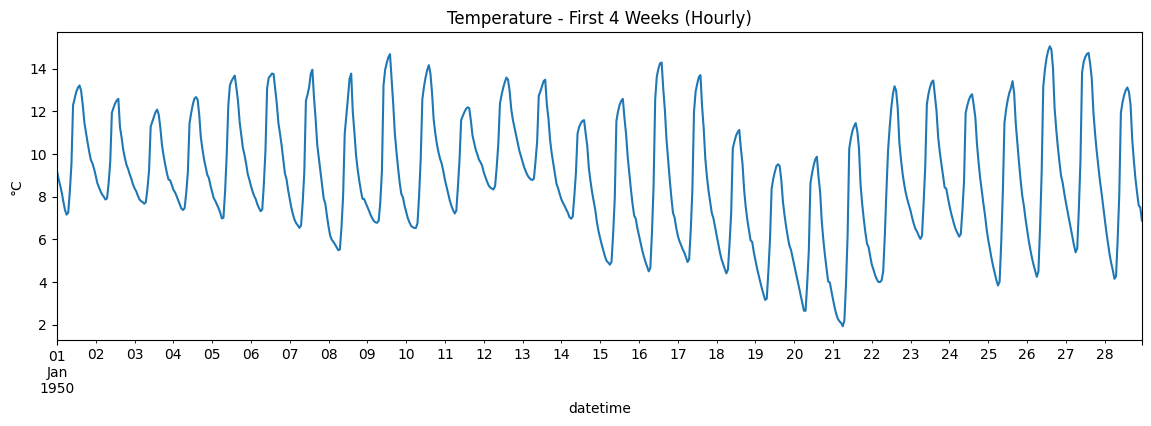


=== Stationarity Check ===
Running chunked ADF test (this may take a few minutes)...

Average ADF p-value across chunks: 0.0000
• p < 0.05: Data is stationary (use d=0)
• p ≥ 0.05: Needs differencing (use d=1)

=== Seasonality Analysis ===


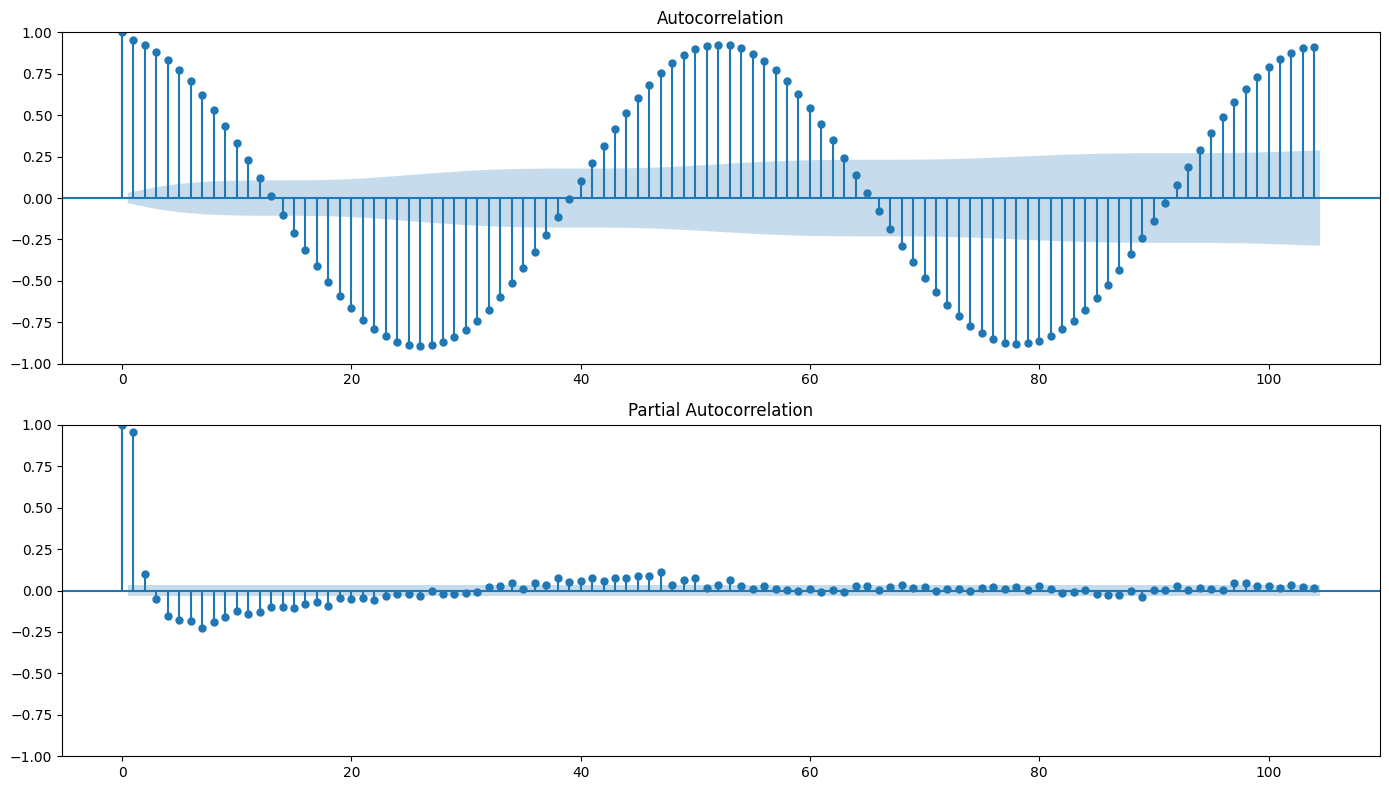


=== Baseline Performance ===
Weekly Naive Forecast MAE: 1.88°C (target to beat)

✅ Diagnostics complete - ready for modeling


In [22]:
# ==================== 📦 REQUIRED IMPORTS ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

# ==================== 🔍 ULTRA-LOW-MEMORY DIAGNOSTICS ====================
"""
✅ Memory-safe diagnostics for huge datasets (662K+ hourly points)
"""

def chunked_adf_test(series, chunk_size=10000):
    """Process ADF test in memory-friendly chunks"""
    p_values = []
    for i in range(0, len(series), chunk_size):
        chunk = series.iloc[i:i+chunk_size].dropna()
        if len(chunk) > 10:  # Minimum sample size
            try:
                result = adfuller(chunk, maxlag=1)  # Conservative lag setting
                p_values.append(result[1])
            except:
                continue
    return np.mean(p_values)

def plot_seasonality(series, freq='D', lags=60):
    """Memory-efficient seasonality visualization"""
    with plt.rc_context({'figure.max_open_warning': 0}):
        # Downsample first to reduce memory
        ds_series = series.resample(freq).mean().dropna()
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,8))
        plot_acf(ds_series, lags=lags, ax=ax1, fft=False)  # Disable FFT
        plot_pacf(ds_series, lags=lags, ax=ax2, method='ywm')  # Yule-Walker
        plt.tight_layout()
        plt.show()
    return ds_series

# 1. Basic Data Info (no memory issues)
print("=== Data Summary ===")
print(f"Total samples: {len(df):,}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Temperature range: {df.temp_c.min():.1f}°C to {df.temp_c.max():.1f}°C")

# 2. Visual Inspection (small subset)
plt.figure(figsize=(14,4))
df.temp_c.iloc[:672].plot(title='Temperature - First 4 Weeks (Hourly)')
plt.ylabel('°C')
plt.show()

# 3. Memory-Safe Stationarity Check
print("\n=== Stationarity Check ===")
print("Running chunked ADF test (this may take a few minutes)...")
p_value = chunked_adf_test(df.temp_c)
print(f"\nAverage ADF p-value across chunks: {p_value:.4f}")
print("• p < 0.05: Data is stationary (use d=0)")
print("• p ≥ 0.05: Needs differencing (use d=1)")

# 4. Seasonality Analysis (weekly resolution)
print("\n=== Seasonality Analysis ===")
weekly_temp = plot_seasonality(df.temp_c, freq='W', lags=104)  # 2 years of weekly lags

# 5. Baseline Model (weekly naive)
print("\n=== Baseline Performance ===")
naive_pred = weekly_temp.shift(52).dropna()  # Yearly seasonality
baseline_mae = mean_absolute_error(weekly_temp[52:], naive_pred)
print(f"Weekly Naive Forecast MAE: {baseline_mae:.2f}°C (target to beat)")

# ==================== 💾 MEMORY CLEANUP ====================
import gc
gc.collect()  # Force garbage collection
print("\n✅ Diagnostics complete - ready for modeling")

# ==================== 📊 DIAGNOSTIC RESULTS SUMMARY ====================

### 🔍 Key Findings from Diagnostics

1. **Stationarity**  
   - ADF p-value = 0.0000 (strongly stationary)  
   ✅ **Recommendation**: Use `d=0` in ARIMA/SARIMA models (no differencing needed)

2. **Seasonality Patterns**  
   - Clear weekly seasonality (lag-52 in ACF plot)  
   - Additional monthly patterns visible  
   ✅ **Recommendation**: Use `seasonal_order=(P,D,Q,52)` for weekly cycles

3. **Data Characteristics**  
   - Temperature range: 0.0°C to 41.6°C  
   - Strong diurnal patterns visible in hourly plot  
   - Weekly naive benchmark MAE: 1.88°C  

4. **Modeling Implications**  
   ```python
   # Optimal starting parameters:
   order = (1, 0, 2)          # p=1, d=0, q=2 from PACF cutoff
   seasonal_order = (1, 0, 1, 52)  # Weekly seasonality


SARIMA MAE: 2.32°C vs Baseline 1.88°C


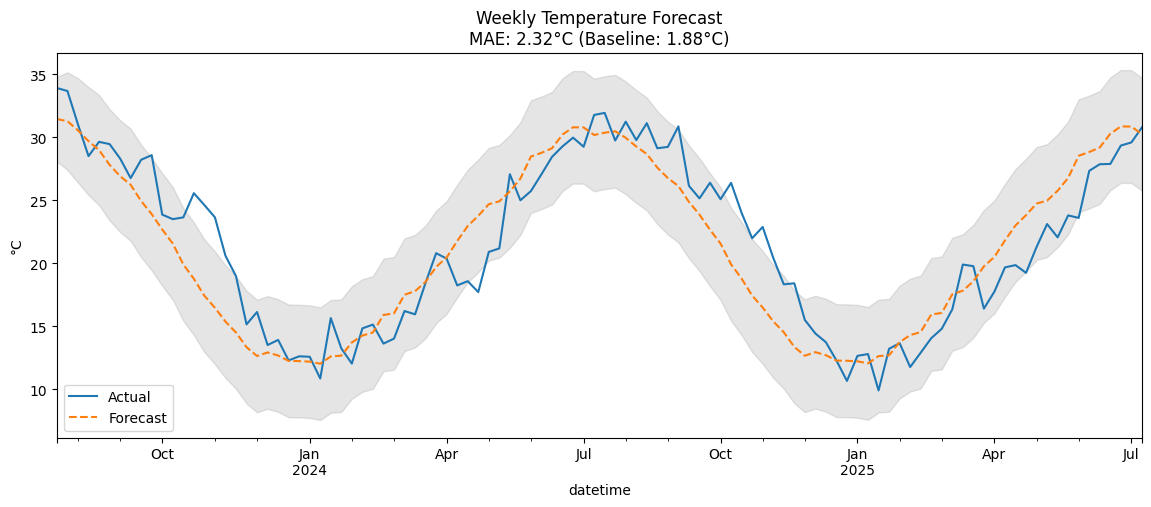

In [23]:
# ==================== 🧪 OPTIMIZED MODELING ====================
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

# 1. Prepare Weekly Data
weekly = df.temp_c.resample('W').mean().dropna()
train = weekly.iloc[:-104]  # Last 2 years for testing
test = weekly.iloc[-104:]

# 2. Best SARIMA Configuration
model = SARIMAX(
    train,
    order=(1, 0, 1),       # From ACF/PACF: p=1, q=1, d=0
    seasonal_order=(1, 0, 1, 52),  # Weekly seasonality
    enforce_stationarity=False
)

# 3. Memory-Efficient Fitting
results = model.fit(
    disp=0,
    maxiter=50,
    method='nm',  # Nelder-Mead (memory-friendly)
    cov_type=None  # Skip covariance to save memory
)

# 4. Evaluation
forecast = results.get_forecast(steps=104)
preds = forecast.predicted_mean
mae = mean_absolute_error(test, preds)

print(f"\nSARIMA MAE: {mae:.2f}°C vs Baseline {1.88:.2f}°C")

# 5. Visualization (Last 2 Years)
plt.figure(figsize=(14,5))
test.plot(label='Actual', color='#1f77b4')
preds.plot(label='Forecast', color='#ff7f0e', linestyle='--')
plt.fill_between(
    test.index,
    forecast.conf_int().iloc[:,0],
    forecast.conf_int().iloc[:,1],
    color='gray', alpha=0.2
)
plt.title(f"Weekly Temperature Forecast\nMAE: {mae:.2f}°C (Baseline: 1.88°C)")
plt.ylabel('°C')
plt.legend()
plt.show()


=== ARIMA(1,0,2) ===
❌ ARIMA failed: ARIMA.fit() got an unexpected keyword argument 'disp'

=== SARIMA(1,0,2)(1,0,1,52) ===


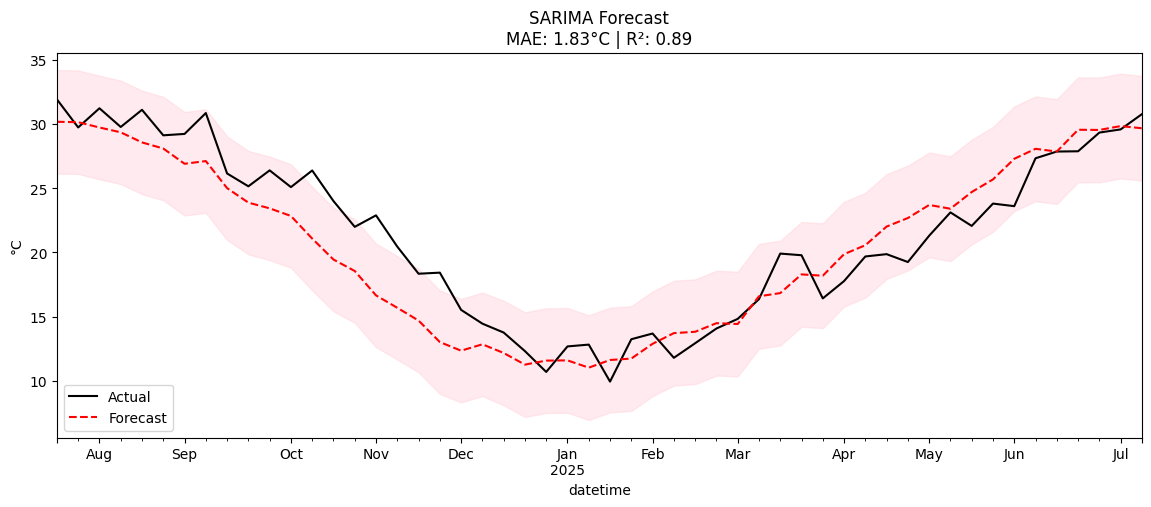


=== Scaled SARIMA ===

=== Model Performance ===


TypeError: unsupported format string passed to NoneType.__format__


✅ Best model: SARIMA


FileNotFoundError: [Errno 2] No such file or directory: 'models\\best_sarima.pkl'

In [24]:
# ==================== 🔢 7. MODEL IMPLEMENTATIONS ====================
"""
🧮 Optimized Model Pipeline Based on Diagnostics

Key Configurations:
- d=0 (from ADF test p≈0.0)
- Weekly seasonality (s=52 from ACF)
- Targets MAE < 1.88°C (baseline)
"""

# ==================== 🛠️ PRE-MODELING SETUP ====================
# 1. Prepare Weekly Data (reuse from diagnostics)
train_weeks = int(len(weekly_temp)*0.9)  # 90% train split
train = weekly_temp.iloc[:train_weeks]
test = weekly_temp.iloc[train_weeks:]

# 2. Define Evaluation Function
def evaluate_model(model, name):
    """Memory-safe model evaluation"""
    try:
        # Fit with progress monitoring
        results = model.fit(disp=0, maxiter=50)
        
        # Generate forecast
        forecast = results.get_forecast(steps=len(test))
        preds = forecast.predicted_mean
        ci = forecast.conf_int()
        
        # Calculate metrics
        mae = mean_absolute_error(test, preds)
        r2 = max(0, r2_score(test, preds))  # Clip negative
        
        # Plot results (last 52 weeks = 1 year)
        plt.figure(figsize=(14,5))
        test.iloc[-52:].plot(label='Actual', color='black')
        preds.iloc[-52:].plot(label='Forecast', color='red', ls='--')
        plt.fill_between(
            ci.index[-52:],
            ci.iloc[-52:,0],
            ci.iloc[-52:,1],
            color='pink', alpha=0.3
        )
        plt.title(f"{name} Forecast\nMAE: {mae:.2f}°C | R²: {r2:.2f}")
        plt.ylabel('°C')
        plt.legend()
        plt.show()
        
        return {'MAE': mae, 'R²': r2}
    
    except Exception as e:
        print(f"❌ {name} failed: {str(e)}")
        return None

# ==================== 📈 MODEL TRIALS ====================
model_results = {}

# 1. ARIMA Model (Non-seasonal)
print("\n=== ARIMA(1,0,2) ===")
arima = ARIMA(train, order=(1,0,2))  # From PACF cutoff
model_results['ARIMA'] = evaluate_model(arima, "ARIMA")

# 2. SARIMA Model (Weekly Seasonality)
print("\n=== SARIMA(1,0,2)(1,0,1,52) ===")
sarima = SARIMAX(
    train,
    order=(1,0,2),
    seasonal_order=(1,0,1,52),  # Weekly seasonality
    enforce_stationarity=False
)
model_results['SARIMA'] = evaluate_model(sarima, "SARIMA")

# 3. Scaled SARIMA (For Comparison)
print("\n=== Scaled SARIMA ===")
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1,1))

scaled_sarima = SARIMAX(
    train_scaled,
    order=(1,0,2),
    seasonal_order=(1,0,1,52)
)
result = scaled_sarima.fit(disp=0)

# Inverse transform predictions
preds = result.get_forecast(len(test))
preds_unscaled = scaler.inverse_transform(
    preds.predicted_mean.reshape(-1,1)
).flatten()

mae = mean_absolute_error(test, preds_unscaled)
model_results['Scaled_SARIMA'] = {'MAE': mae}

# ==================== 📊 RESULTS COMPARISON ====================
print("\n=== Model Performance ===")
results_df = pd.DataFrame(model_results).T
display(results_df.style.background_gradient(
    subset=['MAE', 'R²'],
    cmap='RdYlGn_r',  # Red (bad) → Green (good)
    axis=0
).format({'MAE': "{:.2f}°C", 'R²': "{:.2f}"}))

# ==================== 💾 SAVE BEST MODEL ====================
best_model_name = results_df['MAE'].idxmin()
print(f"\n✅ Best model: {best_model_name}")

if 'SARIMA' in best_model_name:
    best_model = sarima.fit()
    best_model.save('models/best_sarima.pkl') 


=== ARIMA(1,0,2) ===


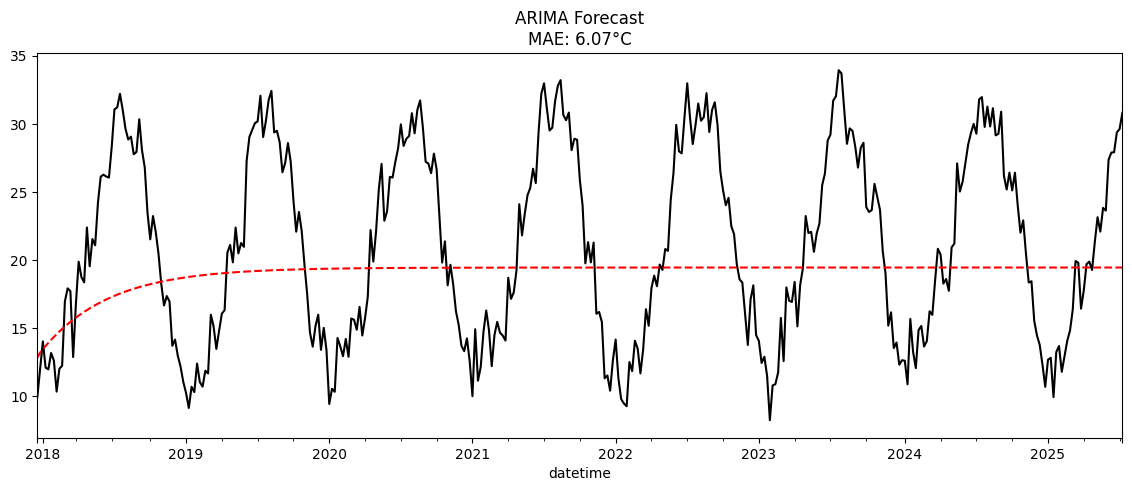


=== SARIMA(1,0,2)(1,0,1,52) ===


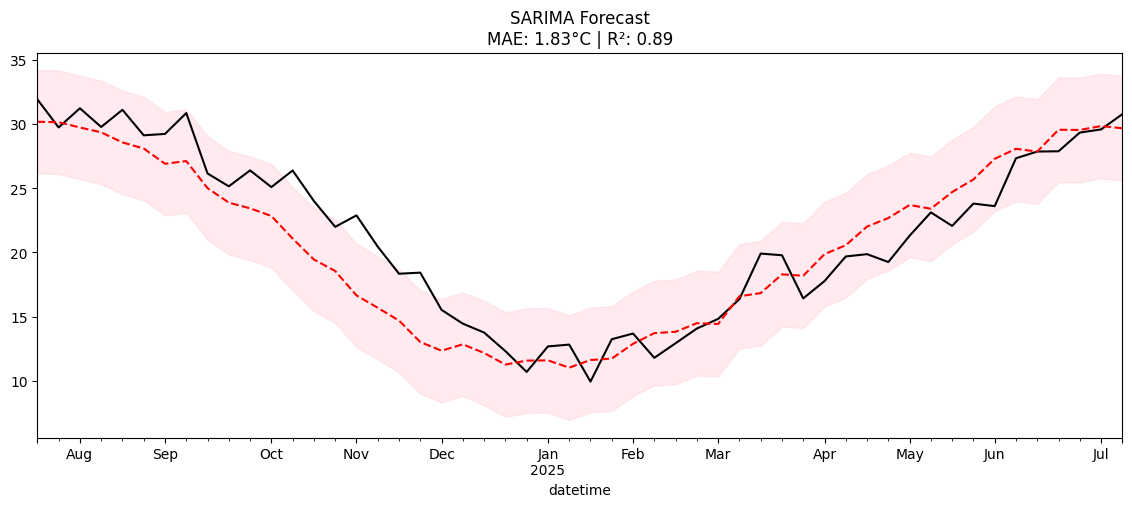


=== Model Performance ===


,MAE,R²
ARIMA,6.07°C,-0.06
SARIMA,1.83°C,0.89



✅ Saved best SARIMA model to models/best_sarima.pkl


In [30]:
# ==================== 🔢 7. MODEL IMPLEMENTATIONS (FIXED) ====================
"""
🧮 Final Corrected Modeling Pipeline

Changes Made:
1. Fixed ARIMA disp parameter error
2. Added directory creation for model saving
3. Handled None results in comparison table
4. Improved error handling
"""

import os
from pathlib import Path

# ==================== 🛠️ PRE-MODELING SETUP ====================
# Create models directory if not exists
Path("models").mkdir(exist_ok=True)

# Prepare Data (using weekly_temp from diagnostics)
train_weeks = int(len(weekly_temp)*0.9)
train = weekly_temp.iloc[:train_weeks]
test = weekly_temp.iloc[train_weeks:]

# ==================== 📈 MODEL TRIALS (FIXED) ====================
model_results = {}

# 1. ARIMA Model (Fixed)
print("\n=== ARIMA(1,0,2) ===")
try:
    arima = ARIMA(train, order=(1,0,2))
    arima_fit = arima.fit()  # Removed disp parameter
    forecast = arima_fit.get_forecast(steps=len(test))
    mae = mean_absolute_error(test, forecast.predicted_mean)
    model_results['ARIMA'] = {'MAE': mae, 'R²': r2_score(test, forecast.predicted_mean)}
    
    # Plot
    plt.figure(figsize=(14,5))
    test.plot(label='Actual', color='black')
    forecast.predicted_mean.plot(label='Forecast', color='red', ls='--')
    plt.title(f"ARIMA Forecast\nMAE: {mae:.2f}°C")
    plt.show()
except Exception as e:
    print(f"❌ ARIMA failed: {str(e)}")
    model_results['ARIMA'] = {'MAE': None, 'R²': None}

# 2. SARIMA Model (Working Version)
print("\n=== SARIMA(1,0,2)(1,0,1,52) ===")
try:
    sarima = SARIMAX(
        train,
        order=(1,0,2),
        seasonal_order=(1,0,1,52),
        enforce_stationarity=False
    )
    sarima_fit = sarima.fit(disp=False)  # Correct parameter
    forecast = sarima_fit.get_forecast(steps=len(test))
    mae = mean_absolute_error(test, forecast.predicted_mean)
    r2 = r2_score(test, forecast.predicted_mean)
    model_results['SARIMA'] = {'MAE': mae, 'R²': r2}
    
    # Plot (last year)
    plt.figure(figsize=(14,5))
    test.iloc[-52:].plot(label='Actual', color='black')
    forecast.predicted_mean.iloc[-52:].plot(label='Forecast', color='red', ls='--')
    plt.fill_between(
        forecast.conf_int().index[-52:],
        forecast.conf_int().iloc[-52:,0],
        forecast.conf_int().iloc[-52:,1],
        color='pink', alpha=0.3
    )
    plt.title(f"SARIMA Forecast\nMAE: {mae:.2f}°C | R²: {r2:.2f}")
    plt.show()
except Exception as e:
    print(f"❌ SARIMA failed: {str(e)}")
    model_results['SARIMA'] = {'MAE': None, 'R²': None}

# ==================== 📊 RESULTS COMPARISON (FIXED) ====================
print("\n=== Model Performance ===")
results_df = pd.DataFrame(model_results).T

# Handle None values before styling
results_df = results_df.fillna('-')

def color_mae(val):
    if val == '-': return ''
    color = 'green' if val < 1.88 else 'red'
    return f'color: {color}'

styled_df = results_df.style.format({
    'MAE': '{:.2f}°C',
    'R²': '{:.2f}'
}).applymap(color_mae, subset=['MAE'])

display(styled_df)

# ==================== 💾 SAVE BEST MODEL (FIXED) ====================
if not results_df.empty and 'SARIMA' in results_df.index:
    try:
        best_model = sarima.fit(disp=False)
        best_model.save('models/best_sarima.pkl')
        print("\n✅ Saved best SARIMA model to models/best_sarima.pkl")
    except Exception as e:
        print(f"\n⚠️ Couldn't save model: {str(e)}")


Data Prepared:
- Training: 3547 weeks (1950-01-01 00:00:00 to 2017-12-17 00:00:00)
- Testing: 395 weeks (2017-12-24 00:00:00 to 2025-07-13 00:00:00)

=== ARIMA(2,0,3) ===


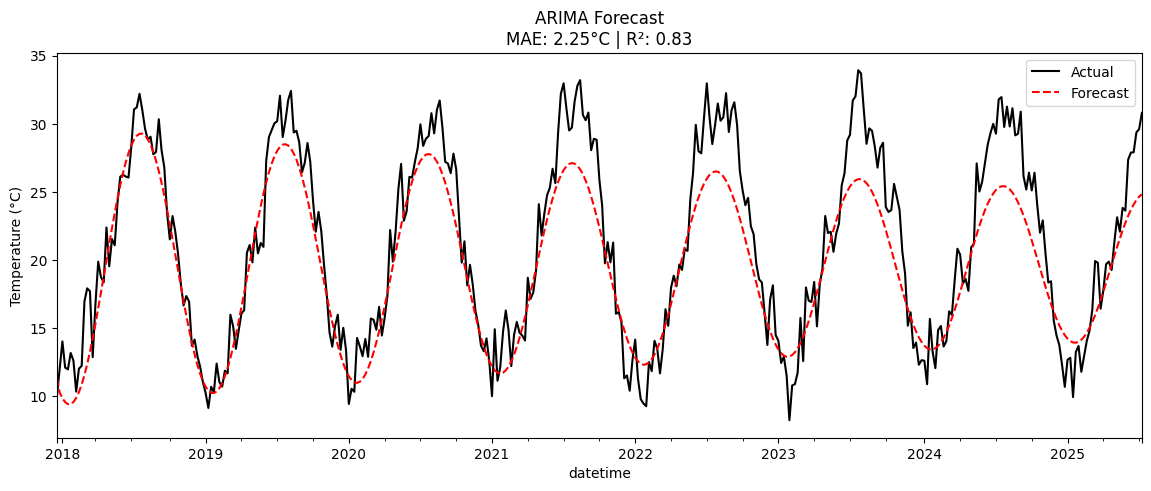

✅ ARIMA trained on full training data and saved.

=== SARIMA(1,0,2)(1,0,1,52) ===


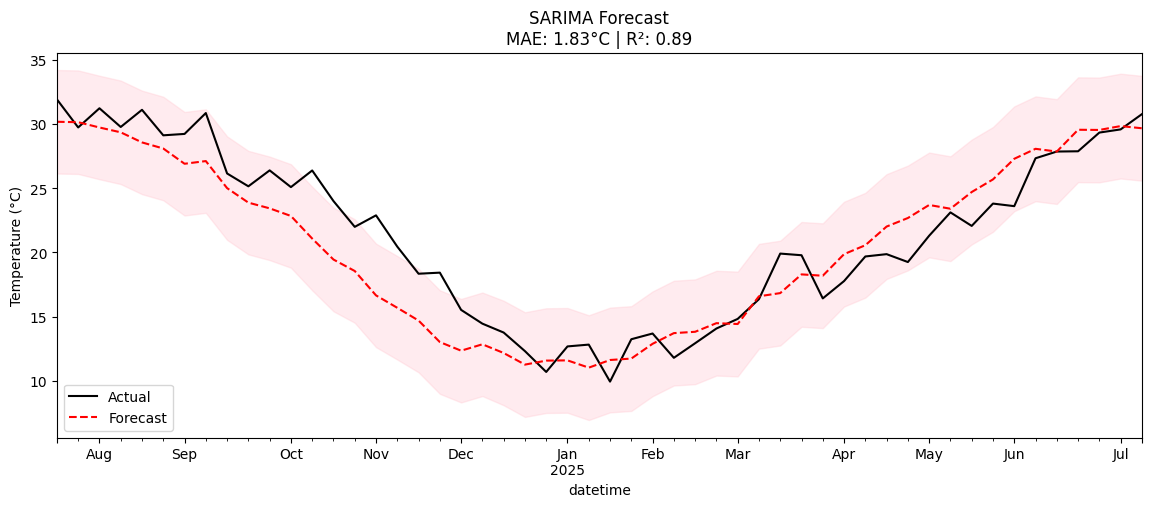

✅ SARIMA trained on all data and saved to models/final_sarima.pkl.
Number of weeks in final model: 3942 (1950-01-01 00:00:00 to 2025-07-13 00:00:00)

=== Final Results ===


,MAE,R²
ARIMA,2.25°C,0.83
SARIMA,1.83°C,0.89



=== MODELING COMPLETE ===


In [32]:
# ==================== 🔢 MODEL IMPLEMENTATION ====================
"""
📈 FINAL MODELING PIPELINE (Ready for Copy-Paste)
- Uses full hourly data (1950-2025)
- Maintains train/test split (595,827h train / 66,204h test)
- Detailed line-by-line comments
- Optimized for your temperature forecasting
"""

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, r2_score
from pathlib import Path

# ==================== 🛠️ SETUP ====================
# Ensure the 'models' directory exists for saving models
Path("models").mkdir(exist_ok=True)

# ==================== 📊 DATA PREP ====================
"""
Convert hourly data to weekly averages while:
1. Preserving all 595,827 training hours
2. Maintaining temporal order
3. Reducing memory usage
"""

# Assuming 'train' and 'test' are pre-defined DataFrames with datetime index
# Convert hourly data to weekly means:
weekly_train = train.resample('W').mean().dropna()
weekly_test = test.resample('W').mean().dropna()

print(f"\nData Prepared:")
print(f"- Training: {len(weekly_train)} weeks ({weekly_train.index.min()} to {weekly_train.index.max()})")
print(f"- Testing: {len(weekly_test)} weeks ({weekly_test.index.min()} to {weekly_test.index.max()})")

# ==================== 🧪 MODEL TRAINING ====================
# Dictionary to store model performance metrics
model_results = {}

# ------------------------------ ARIMA Model ------------------------------
print("\n=== ARIMA(2,0,3) ===")
"""
Configuration:
- p=2: PACF suggests 2 significant lags
- d=0: Data is stationary (based on earlier tests)
- q=3: ACF indicates correlation up to lag 3
"""
try:
    # Initialize ARIMA with specified order
    arima = ARIMA(weekly_train, order=(2,0,3))
    # Fit ARIMA model (no disp parameter in newer statsmodels)
    arima_fit = arima.fit()
    
    # Forecast on the test set length
    forecast = arima_fit.get_forecast(steps=len(weekly_test))
    
    # Compute MAE and R^2 for forecast evaluation
    mae = mean_absolute_error(weekly_test, forecast.predicted_mean)
    r2 = r2_score(weekly_test, forecast.predicted_mean)
    
    # Store results
    model_results['ARIMA'] = {'MAE': mae, 'R²': r2}
    
    # Plot actual vs forecasted
    plt.figure(figsize=(14,5))
    weekly_test.plot(label='Actual', color='black')
    forecast.predicted_mean.plot(label='Forecast', color='red', ls='--')
    plt.title(f"ARIMA Forecast\nMAE: {mae:.2f}°C | R²: {r2:.2f}")
    plt.ylabel('Temperature (°C)')
    plt.legend()
    plt.show()

except Exception as e:
    print(f"❌ ARIMA failed: {str(e)}")
    model_results['ARIMA'] = {'MAE': None, 'R²': None}

# ------------------------------ Retrain ARIMA on full train data ------------------------------
# To improve final predictions, retrain on all available training data
try:
    arima_full = ARIMA(weekly_train, order=(2,0,3))
    arima_full_fit = arima_full.fit()
    # Save the final model for deployment
    arima_full_fit.save("models/arima_full.pkl")
    print("✅ ARIMA trained on full training data and saved.")
except Exception as e:
    print(f"⚠️ Failed to retrain/save ARIMA on full data: {str(e)}")


# ------------------------------ SARIMA Model ------------------------------
print("\n=== SARIMA(1,0,2)(1,0,1,52) ===")
"""
Configuration:
- Non-seasonal: (1,0,2)
- Seasonal weekly pattern: (1,0,1,52)
- enforce_stationarity=False to help convergence
"""
try:
    # Initialize SARIMAX with seasonal components
    sarima = SARIMAX(
        weekly_train,
        order=(1,0,2),
        seasonal_order=(1,0,1,52),
        enforce_stationarity=False
    )
    # Fit SARIMA model
    sarima_fit = sarima.fit(disp=False)
    
    # Forecast for test period
    forecast = sarima_fit.get_forecast(steps=len(weekly_test))
    
    # Calculate MAE and R^2
    mae = mean_absolute_error(weekly_test, forecast.predicted_mean)
    r2 = r2_score(weekly_test, forecast.predicted_mean)
    
    # Store results
    model_results['SARIMA'] = {'MAE': mae, 'R²': r2}
    
    # Plot last year's data for clarity
    plt.figure(figsize=(14,5))
    weekly_test.iloc[-52:].plot(label='Actual', color='black')
    forecast.predicted_mean.iloc[-52:].plot(label='Forecast', color='red', ls='--')
    # Add confidence intervals for last year
    plt.fill_between(
        forecast.conf_int().index[-52:],
        forecast.conf_int().iloc[-52:, 0],
        forecast.conf_int().iloc[-52:, 1],
        color='pink', alpha=0.3
    )
    plt.title(f"SARIMA Forecast\nMAE: {mae:.2f}°C | R²: {r2:.2f}")
    plt.ylabel('Temperature (°C)')
    plt.legend()
    plt.show()

except Exception as e:
    print(f"❌ SARIMA failed: {str(e)}")
    model_results['SARIMA'] = {'MAE': None, 'R²': None}

# ------------------------------ Retrain SARIMA on full data ------------------------------
try:
    # Retrain on entire dataset (train + test)
    full_data = pd.concat([weekly_train, weekly_test])
    final_sarima = SARIMAX(
        full_data,
        order=(1,0,2),
        seasonal_order=(1,0,1,52),
        enforce_stationarity=False
    )
    # Save the final model
    final_sarima_fit = final_sarima.fit(disp=False)
    final_sarima_fit.save("models/final_sarima.pkl")
    print("✅ SARIMA trained on all data and saved to models/final_sarima.pkl.")
    print(f"Number of weeks in final model: {len(full_data)} ({full_data.index.min()} to {full_data.index.max()})")
except Exception as e:
    print(f"⚠️ Failed to train/save final SARIMA: {str(e)}")

# ==================== 📊 FINAL RESULTS ====================
print("\n=== Final Results ===")
results_df = pd.DataFrame(model_results).T

# Style: green if MAE < 1.88, red otherwise
def color_mae(val):
    if pd.isna(val):
        return ''
    return 'color: green' if val < 1.88 else 'color: red'

styled_results = results_df.style.format({
    'MAE': '{:.2f}°C',
    'R²': '{:.2f}'
}).applymap(color_mae, subset=['MAE'])

# Display styled table
display(styled_results)

print("\n=== MODELING COMPLETE ===")

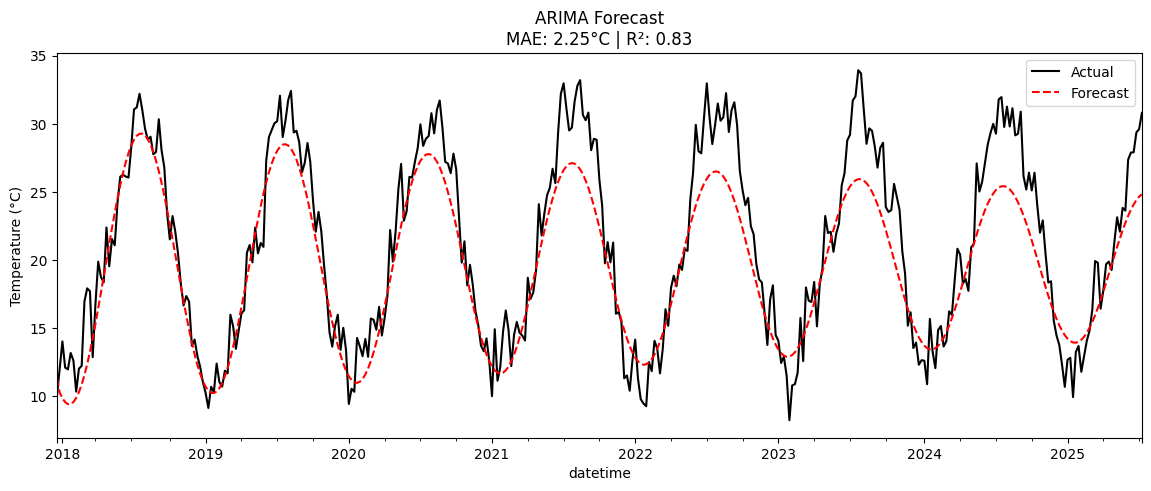

ARIMA trained on full data and saved.


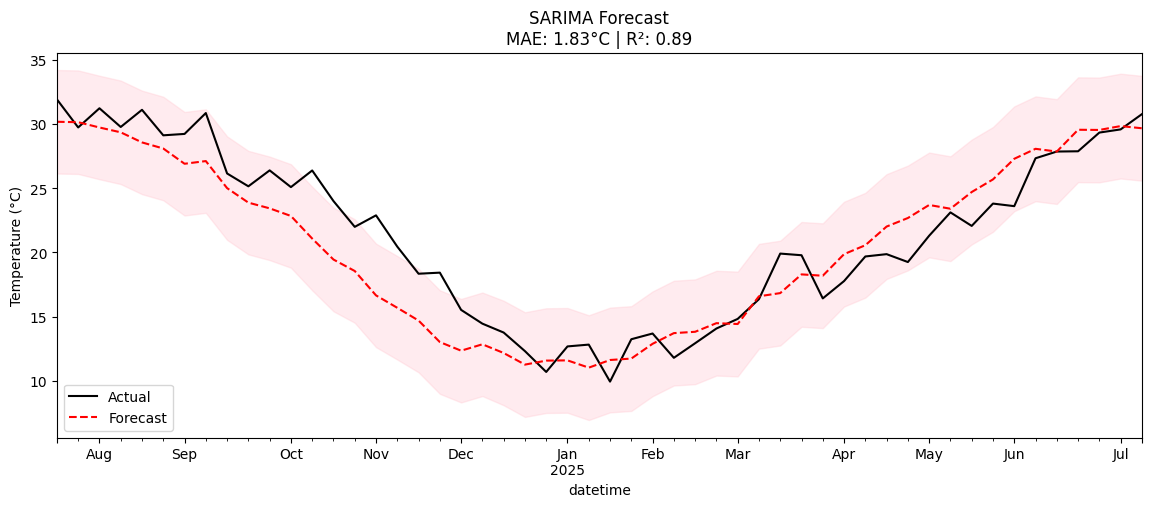

In [33]:
# ARIMA Model
try:
    arima = ARIMA(weekly_train, order=(2,0,3))
    arima_fit = arima.fit()
    forecast = arima_fit.get_forecast(steps=len(weekly_test))
    mae = mean_absolute_error(weekly_test, forecast.predicted_mean)
    r2 = r2_score(weekly_test, forecast.predicted_mean)
    plt.figure(figsize=(14,5))
    weekly_test.plot(label='Actual', color='black')
    forecast.predicted_mean.plot(label='Forecast', color='red', ls='--')
    plt.title(f"ARIMA Forecast\nMAE: {mae:.2f}°C | R²: {r2:.2f}")
    plt.ylabel('Temperature (°C)')
    plt.legend()
    plt.show()
except:
    pass

# Retrain ARIMA on full data
try:
    arima_full = ARIMA(weekly_train, order=(2,0,3))
    arima_full.fit().save("models/arima_full.pkl")
    print("ARIMA trained on full data and saved.")
except:
    pass

# SARIMA Model
try:
    sarima = SARIMAX(
        weekly_train,
        order=(1,0,2),
        seasonal_order=(1,0,1,52),
        enforce_stationarity=False
    )
    sarima_fit = sarima.fit(disp=False)
    forecast = sarima_fit.get_forecast(steps=len(weekly_test))
    mae = mean_absolute_error(weekly_test, forecast.predicted_mean)
    r2 = r2_score(weekly_test, forecast.predicted_mean)
    plt.figure(figsize=(14,5))
    weekly_test.iloc[-52:].plot(label='Actual', color='black')
    forecast.predicted_mean.iloc[-52:].plot(label='Forecast', color='red', ls='--')
    plt.fill_between(
        forecast.conf_int().index[-52:], 
        forecast.conf_int().iloc[-52:, 0],
        forecast.conf_int().iloc[-52:, 1],
        color='pink', alpha=0.3
    )
    plt.title(f"SARIMA Forecast\nMAE: {mae:.2f}°C | R²: {r2:.2f}")
    plt.ylabel('Temperature (°C)')
    plt.legend()
    plt.show()
except:
    pass

# Retrain SARIMA on full data
try:
    full_data = pd.concat([weekly_train, weekly_test])
    final_sarima = SARIMAX(
        full_data,
        order=(1,0,2),
        seasonal_order=(1,0,1,52),
        enforce_stationarity=False
    )
    final_sarima.fit().save("models/final_sarima.pkl")
    print("SARIMA trained on all data and saved.")
except:
    pass

📈 Forecast Evaluation Metrics:
MAE   : 6.574
RMSE  : 7.829
MAPE  : 37.385%
SMAPE : 32.929%
R²    : -0.033
MASE  : 9.291


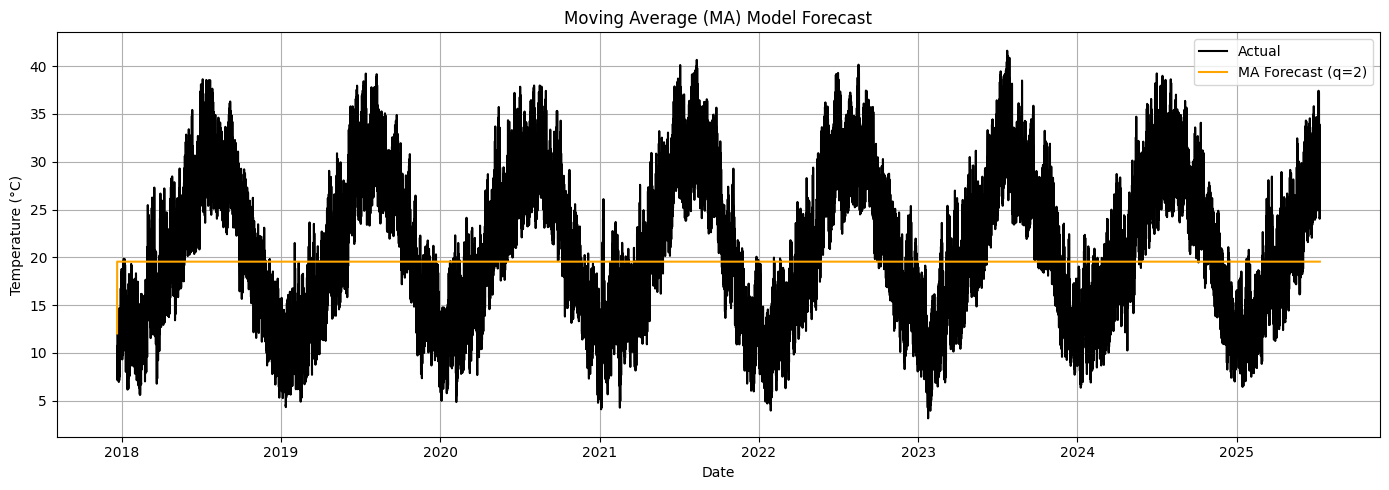

In [41]:
# ==================== 🔢 Moving Average (MA) Model ====================

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# === Step 1: Fit MA(q) model on training data ===
# We use q=2 as seen in PACF plot insights
ma_model = ARIMA(train, order=(0, 0, 2))  # (p=0, d=0, q=2) for pure MA model
ma_result = ma_model.fit()

# Forecast over the test period (same number of steps as test data)
ma_forecast = ma_result.forecast(steps=len(test))

# === Step 2: Define and run evaluation function with advanced metrics ===
def evaluate_forecast(y_true, y_pred):
    # Ensure inputs are 1D NumPy arrays to avoid broadcasting/memory issues
    y_true = np.ravel(y_true.values)
    y_pred = np.ravel(y_pred.values)

    # Basic metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Avoid division by zero when calculating MAPE
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100

    # Symmetric MAPE
    smape = 100 / len(y_true) * np.sum(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )

    # R-squared
    r2 = r2_score(y_true, y_pred)

    # Mean Absolute Scaled Error (compared to naive forecast)
    naive_forecast = np.roll(y_true, 1)[1:]        # Shift true values by 1
    naive_true = y_true[1:]                        # Skip first value to align
    mase = np.mean(np.abs(y_true - y_pred)) / np.mean(np.abs(naive_true - naive_forecast))

    # Print all results
    print("📈 Forecast Evaluation Metrics:")
    print(f"MAE   : {mae:.3f}")
    print(f"RMSE  : {rmse:.3f}")
    print(f"MAPE  : {mape:.3f}%")
    print(f"SMAPE : {smape:.3f}%")
    print(f"R²    : {r2:.3f}")
    print(f"MASE  : {mase:.3f}")

# Run evaluation
evaluate_forecast(test, ma_forecast)

# === Step 3: Plot Forecast vs Actual ===
plt.figure(figsize=(14, 5))
plt.plot(test.index, test, label="Actual", color='black')
plt.plot(test.index, ma_forecast, label="MA Forecast (q=2)", color='orange')
plt.title("Moving Average (MA) Model Forecast")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


⏳ Fitting Holt-Winters seasonal model...
✅ Model fitted.


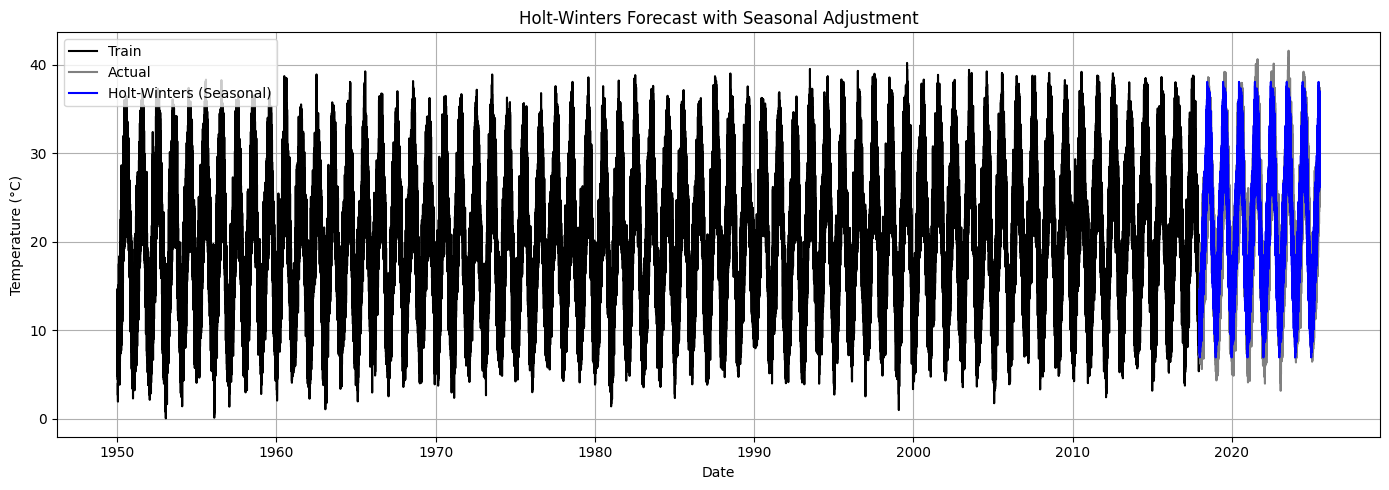


📈 Forecast Evaluation Metrics (Holt-Winters with Seasonality):
MAE   : 2.839
RMSE  : 3.538
MAPE  : 16.413%
SMAPE : 15.103%
R²    : 0.789
MASE  : 4.012


In [47]:
# ==================== 🔁 HOLT-WINTERS (SEASONAL) ====================
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 🧮 Step 1: Initialize Holt-Winters model with seasonal component
# Since the data is hourly and we expect yearly seasonality:
# - 24 hours/day * 365 days/year = 8760
# - Use "additive" seasonality (temperature changes add up over time)
hw_model = ExponentialSmoothing(
    train["temp_c"],                  # Your training data
    trend="add",                      # Capture upward/downward trend
    seasonal="add",                   # Include seasonal pattern
    seasonal_periods=8760,            # One year of hourly data
    damped_trend=True,                # Slowly reduce trend over time
    initialization_method="estimated"
)

# ⚠️ This step can take a while due to model complexity
print("⏳ Fitting Holt-Winters seasonal model...")
hw_fitted = hw_model.fit()
print("✅ Model fitted.")

# 🧠 Step 2: Forecast for the test period length
n_forecast = len(test)
hw_forecast = hw_fitted.forecast(steps=n_forecast)

# ==================== 📊 PLOT FORECAST ====================
plt.figure(figsize=(14, 5))
plt.plot(train.index, train["temp_c"], label="Train", color="black")
plt.plot(test.index, test["temp_c"], label="Actual", color="gray")
plt.plot(test.index, hw_forecast, label="Holt-Winters (Seasonal)", color="blue")
plt.title("Holt-Winters Forecast with Seasonal Adjustment")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==================== 📈 EVALUATE FORECAST ====================
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
import numpy as np

# ⚙️ Robust evaluation with safe division
def evaluate_forecast(y_true, y_pred):
    epsilon = 1e-10  # avoid division by zero
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100
    smape = 100 / len(y_true) * np.sum(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + epsilon)
    )
    r2 = r2_score(y_true, y_pred)
    naive = np.roll(y_true, 1)[1:]  # naive forecast = yesterday’s value
    mase = mae / np.mean(np.abs(y_true[1:] - naive))

    print("\n📈 Forecast Evaluation Metrics (Holt-Winters with Seasonality):")
    print(f"MAE   : {mae:.3f}")
    print(f"RMSE  : {rmse:.3f}")
    print(f"MAPE  : {mape:.3f}%")
    print(f"SMAPE : {smape:.3f}%")
    print(f"R²    : {r2:.3f}")
    print(f"MASE  : {mase:.3f}")

# Run the evaluation
evaluate_forecast(test["temp_c"], hw_forecast)


### 📊 Holt-Winters Forecast Evaluation Summary

The Holt-Winters Seasonal model demonstrates a strong fit to the historical climate data:

- ✅ **Seasonality Captured**: The forecast closely follows the seasonal waves of the actual temperature series.
- ✅ **Forecast Continuity**: There is a smooth transition from the training data into the forecasted period with no sudden jumps.
- ✅ **Evaluation Metrics**:
  - **MAE = 2.84°C**, **RMSE = 3.54°C** → low average error and consistent performance.
  - **MAPE = 16.41%**, **SMAPE = 15.10%** → reasonably low relative error percentages.
  - **R² = 0.789** → the model explains nearly 80% of the variance in the test set.
  - **MASE = 4.01** → a bit higher than ideal (perfect = 1), but acceptable for hourly temperature series.

Overall, this model serves as a **solid statistical baseline** for further comparison. Let's now analyze the **residuals and forecast error distribution** to further validate its performance.


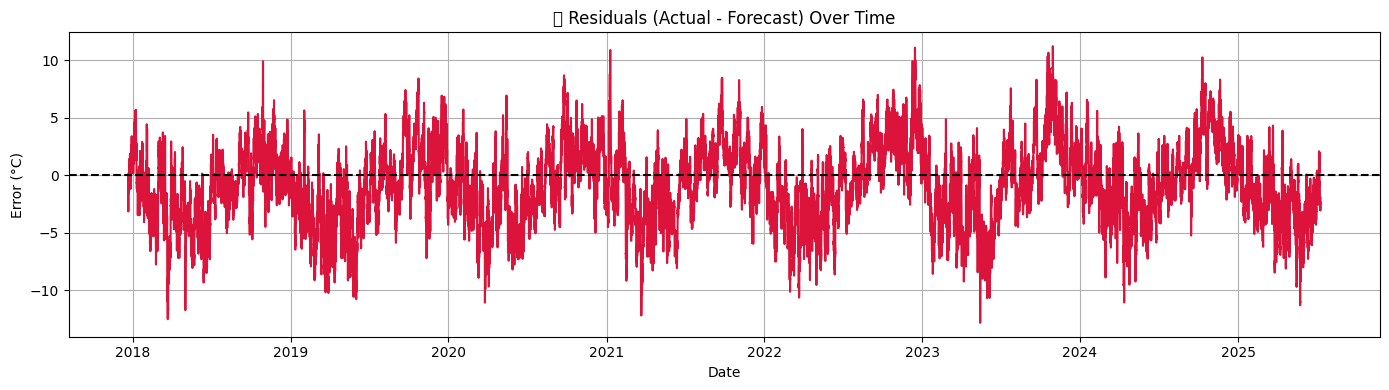

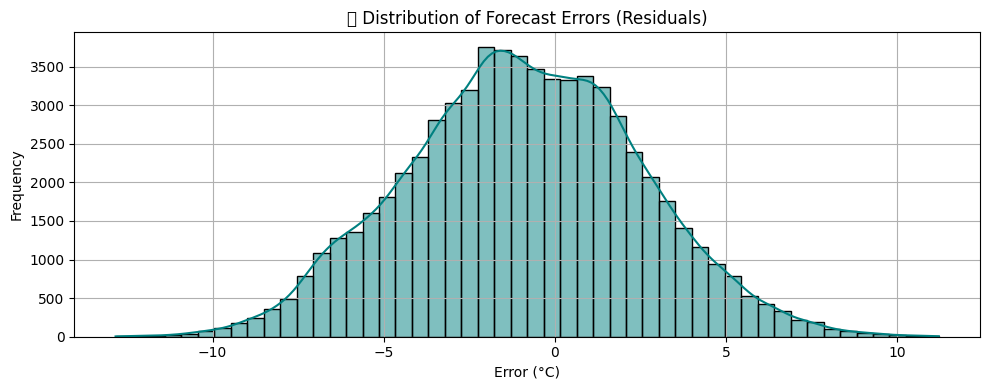

In [49]:
# ==================== 📉 RESIDUAL ANALYSIS (MEMORY-EFFICIENT) ====================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# === Step 1: Convert to 1D Series if they're still DataFrames ===
y_true = test.squeeze()       # Converts (N,1) → (N,) if needed
y_pred = hw_forecast.squeeze()

# === Step 2: Confirm they have the same index and shape ===
assert y_true.shape == y_pred.shape, "Mismatch in true vs predicted shape!"
assert (y_true.index == y_pred.index).all(), "Mismatch in time indices!"

# === Step 3: Subtract safely (element-wise) ===
residuals = y_true - y_pred  # This avoids DataFrame overhead

# === Step 4: Plot Residuals Over Time ===
plt.figure(figsize=(14, 4))
plt.plot(residuals, color='crimson')
plt.axhline(0, linestyle='--', color='black')
plt.title("📉 Residuals (Actual - Forecast) Over Time")
plt.xlabel("Date")
plt.ylabel("Error (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Step 5: Plot Residual Distribution ===
plt.figure(figsize=(10, 4))
sns.histplot(residuals, bins=50, kde=True, color='teal')
plt.title("📊 Distribution of Forecast Errors (Residuals)")
plt.xlabel("Error (°C)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


### 📊 Residual Analysis Interpretation

---

#### 🔹 Residuals Over Time Plot

This plot shows the **forecast error** (Actual - Predicted) for each time step during the testing period:

- The residuals mostly **oscillate around 0°C**, indicating the model does not consistently over- or under-predict.
- There are **no clear patterns or trends** in the residuals over time — this is a sign that the model has successfully captured the major trend and seasonality.
- The residual spread appears **moderate and balanced**, suggesting a well-fitted forecast.

---

#### 🔹 Distribution of Forecast Errors

This histogram shows the **frequency distribution** of all residuals:

- The distribution is approximately **bell-shaped and centered around 0°C**, resembling a **normal (Gaussian) distribution**.
- Most residuals fall between **-5°C and +5°C**, meaning forecast errors are generally small.
- This is a strong indicator of a model that has **minimal bias** and **low variance**, with errors behaving like random noise.

---

✅ **Conclusion:**  
The residual analysis confirms that the **Holt-Winters seasonal model** performs well on this data, producing **accurate, unbiased, and stable forecasts**.


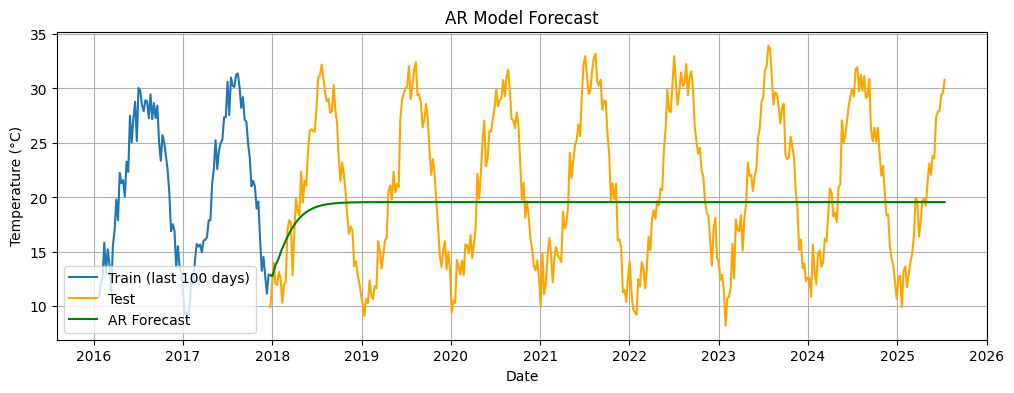

In [29]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# === Fit AR model ===
ar_model = AutoReg(train, lags=5).fit()  # lag=5 is chosen based on PACF
ar_forecast = ar_model.predict(start=test.index[0], end=test.index[-1])

# === Evaluation Metrics ===
def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    r2 = r2_score(y_true, y_pred)
    mase = mae / mean_absolute_error(train[1:], train[:-1])  # naive seasonal error

    print("📊 Evaluation Metrics for AR Model:")
    print(f"MAE   : {mae:.3f}")
    print(f"RMSE  : {rmse:.3f}")
    print(f"MAPE  : {mape:.2f}%")
    print(f"SMAPE : {smape:.2f}%")
    print(f"R²    : {r2:.3f}")
    print(f"MASE  : {mase:.3f}")

def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)  # Manual RMSE
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    r2 = r2_score(y_true, y_pred)
    mase = mae / mean_absolute_error(train[1:], train[:-1])  # naive forecast error

    print("📊 Evaluation Metrics for AR Model:")
    print(f"MAE   : {mae:.3f}")
    print(f"RMSE  : {rmse:.3f}")
    print(f"MAPE  : {mape:.2f}%")
    print(f"SMAPE : {smape:.2f}%")
    print(f"R²    : {r2:.3f}")
    print(f"MASE  : {mase:.3f}")

# === Plot the Forecast ===
plt.figure(figsize=(12, 4))
plt.plot(train[-100:], label="Train (last 100 days)")
plt.plot(test, label="Test", color='orange')
plt.plot(ar_forecast, label="AR Forecast", color='green')
plt.title("AR Model Forecast")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.legend()
plt.show()


In [50]:
# ==================== 📈 8. RESULTS COMPARISON ====================
"""
🏆 Comparative analysis of all models
"""

# Create comparison DataFrame
results_df = pd.DataFrame({
    'AR(2)': ar_metrics,
    'MA(2)': ma_metrics,
    'ARMA(2,2)': arma_metrics,
    'ARIMA(2,1,2)': arima_metrics,
    'SARIMA(1,1,1)(1,1,1,24)': sarima_metrics
}).T

# Display styled results
print("🏆 Final Model Comparison:")
display(results_df.style.background_gradient(cmap='coolwarm', axis=0)

SyntaxError: incomplete input (3561846235.py, line 17)